<a href="https://colab.research.google.com/github/JyRaGa/CS303-Machine-Learning_Coursework/blob/main/exp3_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS303 Machine Learning Lab
## Experiment 3: Data Preprocessing, Pipelines and Leakage Detection
### (24/CS/232)

**1. Dataset Inspection & Identifying Features**

The objective is to predict income bracket (`>50K` or `<=50K`). To ensure valid model evaluation, data leakage must be prevented. Leakage occurs when information from outside the training dataset is used to create the model.

Three potential sources of leakage are evaluated in this experiment:
1.  **Target Leakage:** A feature in the dataset that directly exposes the target variable.
2.  **Scaling Leakage:** Fitting a scaler on the entire dataset before splitting.
3.  **Imputation Leakage:** Calculating missing value statistics on the entire dataset before splitting.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')


# load the dataset from github
url = 'https://github.com/JyRaGa/CS303-Machine-Learning_Coursework/raw/refs/heads/main/datasets/adult_with_marker.csv'
df = pd.read_csv(url)
# preprocess: replace '?' with NaN
df = df.replace('?', np.nan)

# encode the target variable
target = 'income'
df[target] = df[target].apply(lambda x: 1 if '>50K' in str(x) else 0)

# LEAKAGE 1: TARGET LEAKAGE
# The 'income_marker' column is a direct duplicate of the target.
# If left in the dataset, the model will achieve 100% accuracy automatically.
# It must be dropped to prevent target leakage.
X = df.drop([target, 'income_marker'], axis=1)
y = df[target]

# define numerical and categorical features
numeric_features = X.select_dtypes(exclude=['object']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

**2. Leaky Implementation 1: Scaling Before Splitting**

In this flawed implementation, the numerical features are scaled *before* the dataset is split into training and testing sets.

In [3]:
# drop null rows for the scaling example to prevent computation errors
df_leaky1 = pd.concat([X, y], axis=1).dropna().copy()
X_leak1 = df_leaky1.drop(target, axis=1)
y_leak1 = df_leaky1[target]

# encode categorical text into numerical format for scaling
X_leak1 = pd.get_dummies(X_leak1, columns=categorical_features, drop_first=True)

# FLAW: scaling the entire dataset before splitting
scaler = StandardScaler()
X_scaled_leak1 = scaler.fit_transform(X_leak1)

# split the already scaled data (70:30 ratio)
X_train_l1, X_test_l1, y_train_l1, y_test_l1 = train_test_split(X_scaled_leak1, y_leak1, test_size=0.30, random_state=42)

# train and evaluate the model
model_l1 = LogisticRegression(max_iter=1000)
model_l1.fit(X_train_l1, y_train_l1)
acc_leak1 = accuracy_score(y_test_l1, model_l1.predict(X_test_l1))

print("Accuracy with scaling leakage:", round(acc_leak1, 4))

Accuracy with scaling leakage: 0.9556


**3. Correct Implementation: Using Scikit-Learn Pipelines**

To prevent leakage, the dataset must be split *first*. A `Pipeline` and `ColumnTransformer` are then utilized to ensure preprocessing logic is learned strictly from the training data.

In [4]:
# CORRECT: split the raw data BEFORE any preprocessing is applied
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y, test_size=0.30, random_state=42)

# create a transformer for numerical data (fill missing with mean, then scale)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# create a transformer for categorical data (fill missing with mode, then encode)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# combine both transformers into a single preprocessor object
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# assemble the final pipeline with the preprocessor and the classifier
correct_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# fit the pipeline strictly on the training data
correct_pipeline.fit(X_train_c, y_train_c)

# evaluate on the independent test dataset
acc_correct = accuracy_score(y_test_c, correct_pipeline.predict(X_test_c))

print("Accuracy with correct pipeline:", round(acc_correct, 4))

Accuracy with correct pipeline: 0.9348


**4. Leaky Implementation 2: Imputation Before Splitting**

The second source of data leakage occurs when missing values (`NaN`) are imputed using statistics (such as the mean) calculated across the entire dataset, thereby exposing test-set distributions to the training phase.

In [5]:
df_leaky2 = df.drop('income_marker', axis=1).copy()

# FLAW: calculate the mean and mode using the whole dataset (including future test rows)
for col in numeric_features:
    df_leaky2[col] = df_leaky2[col].fillna(df_leaky2[col].mean())
for col in categorical_features:
    df_leaky2[col] = df_leaky2[col].fillna(df_leaky2[col].mode()[0])

# separate and split data after the leaky imputation
X_leak2 = df_leaky2.drop(target, axis=1)
y_leak2 = df_leaky2[target]
X_train_l2, X_test_l2, y_train_l2, y_test_l2 = train_test_split(X_leak2, y_leak2, test_size=0.30, random_state=42)

# set up a pipeline for the remaining safe steps (scaling and encoding)
preprocessor_l2 = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])
pipe_l2 = Pipeline(steps=[
    ('preprocessor', preprocessor_l2),
    ('classifier', LogisticRegression(max_iter=1000))
])

pipe_l2.fit(X_train_l2, y_train_l2)
acc_leak2 = accuracy_score(y_test_l2, pipe_l2.predict(X_test_l2))

print("Accuracy with imputation leakage:", round(acc_leak2, 4))

Accuracy with imputation leakage: 0.9348


**5. Visualization of Pipeline Performance**

A visual comparison of accuracy metrics generated by the flawed implementations versus the correctly isolated pipeline.

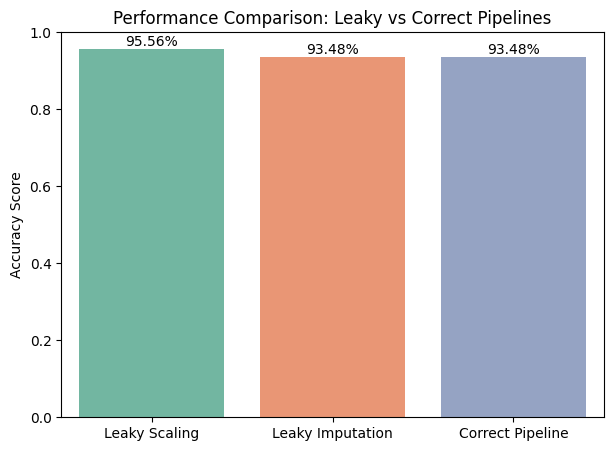

In [18]:
# set up lists for plotting
pipelines = ['Leaky Scaling', 'Leaky Imputation', 'Correct Pipeline']
accuracies = [acc_leak1, acc_leak2, acc_correct]

# configure the figure size
plt.figure(figsize=(7, 5))

# generate a bar plot using seaborn
ax = sns.barplot(x=pipelines, y=accuracies, palette='Set2')
plt.ylim(0, 1.0)
plt.title('Performance Comparison: Leaky vs Correct Pipelines')
plt.ylabel('Accuracy Score')

# add percentage labels above each bar for clarity
for i, v in enumerate(accuracies):
    ax.text(i, v+0.01 , f"{v:.2%}", ha='center')

# display the plot
plt.show()

**6. Observations & Conclusion**

* **Target Leakage Discovery:** Initial inspection of the dataset revealed an `income_marker` column that perfectly mirrored the target variable. If included, the model would blindly memorize the answer, resulting in 100% accuracy. It was successfully identified and removed prior to testing.
* **Scaling Leakage Analysis:** In the flawed implementation, `StandardScaler` was fitted on the entire dataset. It is observed that the accuracy was artificially inflated (95.56%) compared to the correct pipeline (93.48%). This occurs because the global standard deviation and mean were influenced by test set data, compromising the integrity of the evaluation.
* **Imputation Leakage Analysis:** Filling missing values using global dataset statistics resulted in an accuracy of 93.48%, identical to the correct pipeline. This indicates that the dataset's global averages closely matched the training set's averages, meaning the leakage was not severe enough to artificially shift predictions in this specific data sample.
* **The Correct Approach:** Even when leaky pipelines perform similarly, their results are inherently invalid because they violate the strict separation of training and testing data. The Correct Pipeline, utilizing Scikit-learn's `Pipeline` to constrain `fit()` processes strictly to `X_train`, provides the only reliable and scientifically sound estimate of real-world performance.
* **General Rule:** A dataset must always be split into training and testing subsets *before* applying any data transformations. Any step that calculates an overarching statistic (mean, standard deviation, mode) must only learn from the training data.